## Simulating SNIa with skysurvey
In this notebook, we study Supernovae Ia (SNIa).
First, we do without extinction and no gaussian noise.

Use cartopy and these instructions to visualise locations
https://skysurvey.readthedocs.io/en/latest/howto/target_and_skyarea.html

In [2]:
# import required packages:
import skysurvey
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import lightcurve
import lsst_functions
from lightcurve import generate_snia_lightcurve, plot_lightcurve, limit_mag_dict, get_valid_bands
from lightcurve import generate_snia_dict, generate_ordered_parameter_list, determine_visibility

# import cosmology parameters
import sncosmo
from params import p_cosmology

lsst_colors = ["tab:purple", "tab:green", "tab:orange", "tab:red", "tab:brown", "0.5"]
lsst_bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
snia_lightcurve_params = ["z", "x1", "c", "t0", "magabs", "ra", "dec"] #note: lightcurve.py uses "redshift" 

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/ligo/skymap/bayestar/__init__.py:34: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


Load LSST as opsim (to be retrieved from the website: ). Note that the filesizes can be large 
If you want to choose only one band: band IN ('g') AND night < ...

In LSST opsim, the filters have an additional suffixes e.g. _6. For ease of coding, we replace the str using regex.

In [3]:
opsim_path = "baseline_v5.3.5_10yrs.db" # provide fullpath
# opsim_path = "Surveys/baseline_v5.3.5_10yrs.db:Zone.Identifier"
lsst = skysurvey.LSST.from_opsim(opsim_path, sql_where="night < 365")
# Remove the suffix.
lsst.data["band"] = (lsst.data["band"].str.replace(r"_\d+$", "", regex=True))
lsst.data["band"].unique()

<ArrowStringArray>
['lsstu', 'lsstr', 'lsstg', 'lssti', 'lsstz', 'lssty']
Length: 6, dtype: str

In [4]:
#  llod the date range across all the nights
from astropy.time import Time
tmin, tmax = lsst.date_range
print(f"Start: {Time(tmin, format='mjd').iso}")
print(f"End:   {Time(tmax, format='mjd').iso}")
print(f"Duration: {(tmax - tmin)/365.25:.1f} years")
lsst.date_range

Start: 2026-06-17 04:52:30.000
End:   2027-06-10 01:46:52.500
Duration: 1.0 years


(np.float32(61208.203), np.float32(61566.074))

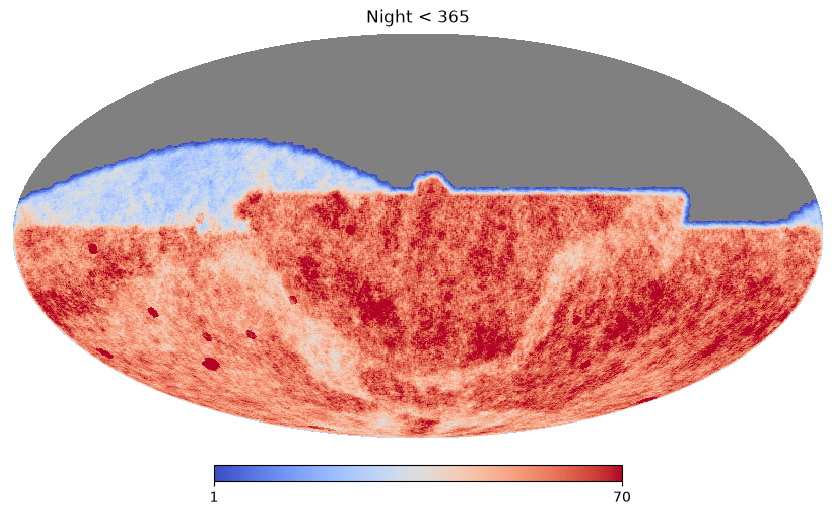

In [ ]:
# uncomment the following if you want to see the field coverage for your given opsim
coverage = lsst.get_fieldcoverage()
lsst.show(vmin=0, vmax=coverage.quantile(0.95), cmap="coolwarm", title = f'Night < 365')
# lsst.data # gives all info about the observation over all the nights (e.g skynoise and in what band). Returns pandas.df
# average over southern sky. could also take average below 30 deg dec --> we dk what new info we will get
# but we will in principle be simulating more sources

To look at observations across all filters in a given field id, use:
<code> select_fieldid = (lsst.data['fieldid'] == 336769) </code>
<code> lsst.data[select_fieldid] </code>

When generating a population, we always use these three back-to-back:
Theoretical lightcurves are simulated from phase [-20, 50], which are days w.r.t peak time. Observations of the target in that particilar field are made at later dates too (but are less likely to have SNR > 5.)

Because we are looking at $\nu$ sources and SNIa are not expected. But SNIa are useful for cosmo studies and the background of transients that we detect

2 completeness we can compute:

simulated vs detected
Until z = 10. We will detect until here. Total detected over the total . can make a fancy plot (with shaded until z = 1.0). We want a value of how many in full universe (4 pi u sr)

In [8]:
snia_dict = generate_snia_dict(redshift = None, ra = None, dec = None, x1 = None, t0 = None, magabs = None, c = None)
snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = lsst_bands, in_mag = False, N_tot = 100, tstart = tmin, tstop = tmax, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)

All params input as None. Using default sampling functions, but with p_cosmology.
CUSTOM MODEL IS {'redshift': {'func': <function sample_redshift_from_Rz at 0x70f420ef1220>, 'kwargs': {'N': 100, 'R_z': <function R_SFR at 0x70f4212d9220>, 'z_max': 1.0, 'p_cosmology': {'c': 299792.458, 'h0': 67.4, 'omega_M': 0.315, 'omega_K': 0, 'omega_L': 0.685, 'z_min': 0.0001, 'N_int_steps': 100, 'R0': {'SN Ia': <Quantity 23000. 1 / (yr Gpc3)>, 'SN CC': <Quantity 101000. 1 / (yr Gpc3)>, 'SN Ibc': <Quantity 101000. 1 / (yr Gpc3)>, 'SN II': <Quantity 101000. 1 / (yr Gpc3)>, 'TDE': <Quantity 8.e-07 1 / (yr Mpc3)>, 'KN': <Quantity 59.3 1 / (yr Gpc3)>}}}, 'as': 'z'}, 'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x70f425150bf0>, 'kwargs': {'dec_range': [-90, 0]}}}


Essential functions:

skysurvey.Target.core.data.loc[index]
- To see a pd.Series of the data specific target transient of a particular index, use .loc[index]. (Note: using .iloc[5] will give the 5th target regardless of index number)

plot_lightcurve() (from <code>lightcurve.py</code>)
- uses the lightcurve times + flux values to plot theoretical lightcurves for a given object. Useful for comparing with theoretical flux/mag limits.

Once you simulated N_tot supernovae, the <code> .from_targets_and_survey() </code> function simulates the observation plan and sees if our SN are visible.

Functions:

- <code>skysurvey.dataset.get_target_lightcurve(self, index, detection=None, phase_range=None)</code> gives a dataframe of diff index_obs with columns: field params.
- <code>skysurvey.dataset.get_data</code> gives a dataframe of obs of a particular index. You can filter depending on <code>detection = bool or None.</code>
- <code>lightcurve.show_target_lightcurve()</code>: Shows theoretical lightcurve of one index + simulated observations from skysurvey.

In [12]:
snia_models.data

,z,x1,c,t0,ra,dec,magabs,magobs,template
0,0.512654,-0.150,0.109,61503.707031,103.076302,-30.532385,-18.901951,23.489670,salt2
1,0.810997,-1.415,0.218,61515.710938,146.960632,-72.301414,-18.314121,25.286379,salt2
2,0.904029,0.365,0.253,61454.523438,208.252502,-15.331963,-18.437319,25.452763,salt2
3,0.691448,0.590,0.021,61504.050781,171.256134,-24.049080,-19.383808,23.793322,salt2
4,0.475007,-1.640,-0.049,61255.792969,329.799835,-7.989157,-19.089890,23.103756,salt2
...,...,...,...,...,...,...,...,...,...
95,0.523263,-0.860,0.209,61487.707031,355.547943,-68.139587,-18.512003,23.932957,salt2
96,0.162115,-1.480,0.042,61510.609375,96.288498,-35.023418,-18.971218,20.550648,salt2
97,0.508864,-0.025,0.079,61440.468750,351.708252,-37.545731,-18.970743,23.401575,salt2
98,0.477317,1.485,0.116,61318.882812,111.633469,-35.394733,-19.093790,23.112415,salt2


In [13]:
from lsst_functions import exist_in_multiband_check, five_sigma_detection_multiband

In [22]:
def get_number_detections_by_band(dataset, index=0, selection_criteria = None):
    """
    Split by band. Total number of detected points for a given dataset.
    You will need to divide by N_tot separately later. 

    Input:
    ---------
        dataset (skysurvey.target.transient): skysurvey target transient object
        index (int): index of the target in the dataset
        selection_criteria (dict): dictionary of selection criteria for detection    
    """
   
    row = {band: 0 for band in lsst_bands} #initiate
    detection_rows = dataset.get_data(index=index,detection=True)

    if len(detection_rows) == 0:
        return row

    indiv_data = detection_rows["band"].value_counts()

    if not exist_in_multiband_check(indiv_data, selection_criteria = selection_criteria): #we should expect >=5 for all plots
        return row

    for band in lsst_bands:
        band_data = detection_rows[detection_rows["band"] == band]
        row[band] = len(band_data)

    return row

In [26]:
dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)

100%|██████████| 100/100 [00:04<00:00, 22.75it/s]


In [27]:
get_number_detections_by_band(dset, index=0, selection_criteria = {"total_points": 5, "n_filters": 2, "min_points_per_filter": 2})

{'lsstu': 0, 'lsstg': 1, 'lsstr': 5, 'lssti': 0, 'lsstz': 2, 'lssty': 0}

In [30]:
snia_models.data[["z", "x1", "c", "t0", "magabs", "magobs", "ra", "dec"]]

,z,x1,c,t0,magabs,magobs,ra,dec
0,0.512654,-0.150,0.109,61503.707031,-18.901951,23.489670,103.076302,-30.532385
1,0.810997,-1.415,0.218,61515.710938,-18.314121,25.286379,146.960632,-72.301414
2,0.904029,0.365,0.253,61454.523438,-18.437319,25.452763,208.252502,-15.331963
3,0.691448,0.590,0.021,61504.050781,-19.383808,23.793322,171.256134,-24.049080
4,0.475007,-1.640,-0.049,61255.792969,-19.089890,23.103756,329.799835,-7.989157
...,...,...,...,...,...,...,...,...
95,0.523263,-0.860,0.209,61487.707031,-18.512003,23.932957,355.547943,-68.139587
96,0.162115,-1.480,0.042,61510.609375,-18.971218,20.550648,96.288498,-35.023418
97,0.508864,-0.025,0.079,61440.468750,-18.970743,23.401575,351.708252,-37.545731
98,0.477317,1.485,0.116,61318.882812,-19.093790,23.112415,111.633469,-35.394733


In [25]:
# if you changed the lsst_functions.py file but do not want to restart the kerne;
import importlib
importlib.reload(lsst_functions)

<module 'lsst_functions' from '/home/denzelgoh/TransientSimulation/lsst_functions.py'>

In [98]:
# import our detection functions from lsst_functions.py

# function that filters out sources based on selection criteria
from lsst_functions import five_sigma_detection_multiband

# functions for number of sources detected
from lsst_functions import detectability_sources # to return a summary of detected sources.

# functions for number of alerts predicted
from lsst_functions import get_number_detections_allbands, n_detections_sources, get_total_alerts_from_survey # this is for if you want to loop through several redshifts. It stores for every redshift.


### Filtering observations

Here, we choose a common selection criteria of 5 total dets, min. 2 dets in 2 bands

In [99]:
# set the N_tot and selection criteria. (5, 2, 2) is the default.
N_tot = 1000

from lsst_functions import set_selection_criteria
selection_criteria = set_selection_criteria(total_points=5, n_filters=2, min_points_per_filter=2)

In [53]:
detected = get_total_alerts_from_survey(snia_param_list = snia_param_list, opsim = lsst, N_tot = N_tot, selection_criteria = selection_criteria)

Start: 2026-06-17 04:52:30.000
End:   2027-06-10 01:46:52.500
Duration: 1.0 years
All params input as None. Using default sampling functions, but with p_cosmology.
CUSTOM MODEL IS {'redshift': {'func': <function sample_redshift_from_Rz at 0x791b17799220>, 'kwargs': {'N': 1000, 'R_z': <function R_SFR at 0x791bc01d6fb0>, 'z_max': 1.0, 'p_cosmology': {'c': 299792.458, 'h0': 67.4, 'omega_M': 0.315, 'omega_K': 0, 'omega_L': 0.685, 'z_min': 0.0001, 'N_int_steps': 100, 'R0': {'SN Ia': <Quantity 23000. 1 / (yr Gpc3)>, 'SN CC': <Quantity 101000. 1 / (yr Gpc3)>, 'SN Ibc': <Quantity 101000. 1 / (yr Gpc3)>, 'SN II': <Quantity 101000. 1 / (yr Gpc3)>, 'TDE': <Quantity 8.e-07 1 / (yr Mpc3)>, 'KN': <Quantity 59.3 1 / (yr Gpc3)>}}}, 'as': 'z'}, 'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x791b1f904d50>, 'kwargs': {'dec_range': [-90, 0]}}}


100%|██████████| 1000/1000 [00:26<00:00, 37.28it/s]


In [54]:
detected

,target,z,ra,dec,t0,detected,n_detections
0,0,0.637563,291.314972,-18.717270,61440.980469,False,0
1,1,0.413343,36.768787,-32.187431,61490.496094,False,0
2,2,0.430781,237.439255,-0.510577,61225.203125,True,6
3,3,0.805807,214.347961,-59.218273,61257.320312,False,0
4,4,0.394355,67.373337,-62.573044,61471.769531,False,0
...,...,...,...,...,...,...,...
995,995,0.167465,55.372765,-9.948995,61392.589844,True,13
996,996,0.517843,128.050018,-23.630953,61281.531250,False,0
997,997,0.715646,325.524658,-18.253996,61451.863281,False,0
998,998,0.991801,31.897120,-20.047499,61518.625000,False,0


In [90]:
# add a column stating which redshift bin to be included in (for histogram purposes)
z_bins = np.arange(0, 1.01, 0.1) # set z bins
detected["z_bin"] = pd.cut(detected["z"],bins=z_bins,right=False)
detected[(detected['detected'] == True) & (detected['n_detections'] < 6)]

,target,z,ra,dec,t0,detected,n_detections,z_bin
38,38,0.280195,25.815048,-46.855446,61430.089844,True,5,"[0.2, 0.3)"
101,101,0.777340,338.067078,-14.457424,61249.710938,True,5,"[0.7, 0.8)"
112,112,0.776960,312.048279,-14.913550,61298.554688,True,5,"[0.7, 0.8)"
208,208,0.489286,140.275589,-21.550217,61393.906250,True,5,"[0.4, 0.5)"
236,236,0.452189,323.469421,-34.332508,61535.187500,True,5,"[0.4, 0.5)"
237,237,0.298023,222.488693,-3.673886,61250.660156,True,5,"[0.2, 0.3)"
395,395,0.574588,147.125580,-4.683903,61545.488281,True,5,"[0.5, 0.6)"
480,480,0.462548,266.573273,-21.972399,61233.667969,True,5,"[0.4, 0.5)"
509,509,0.481057,280.649994,-38.133614,61559.617188,True,5,"[0.4, 0.5)"
532,532,0.393565,236.497543,-41.014519,61224.617188,True,5,"[0.3, 0.4)"


In [ ]:
detected_sources = detected[detected["detected"]]
n_sources = (detected_sources.groupby("z_bin", observed=True).size())
n_points = (detected_sources.groupby("z_bin", observed=True)["n_detections"].sum())

# print(n_sources)
print(n_points)

z_bin
[0.0, 0.1)    216
[0.1, 0.2)    447
[0.2, 0.3)    415
[0.3, 0.4)    417
[0.4, 0.5)    138
[0.5, 0.6)    243
[0.6, 0.7)     83
[0.7, 0.8)     30
[0.9, 1.0)      7
Name: n_detections, dtype: int64


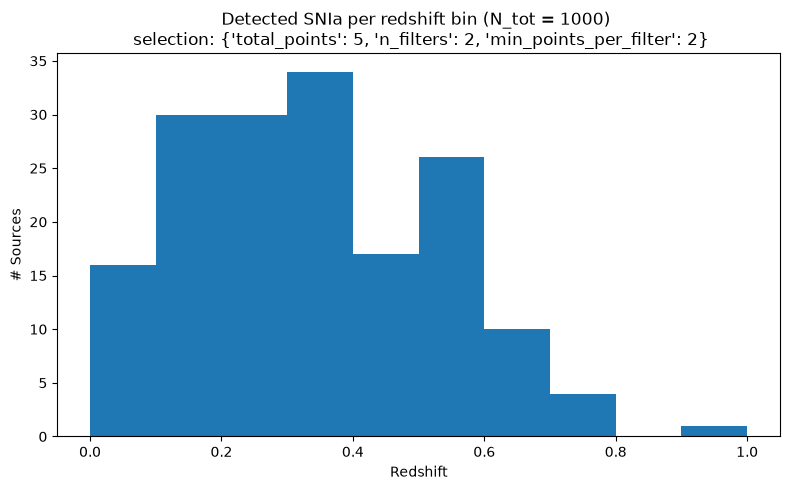

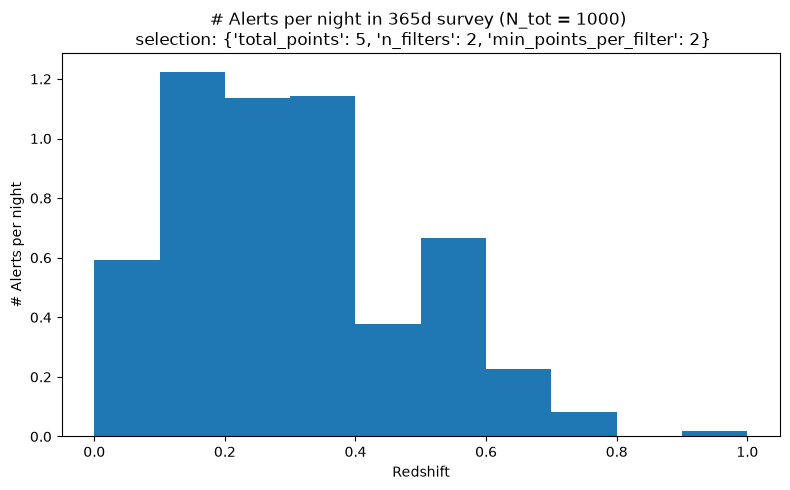

In [ ]:


plt.figure(figsize=(8, 5))

plt.hist(detected_sources["z"],bins=z_bins)

plt.xlabel("Redshift")
plt.ylabel("# Sources")
plt.title(f"Detected SNIa per redshift bin (N_tot = {N_tot}) \n selection: {selection_criteria}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(detected_sources['z'], weights = detected_sources["n_detections"]/365, bins=z_bins)

plt.xlabel("Redshift")
plt.ylabel("# Alerts per night")
plt.title(f"# Alerts per night in 365d survey (N_tot = {N_tot}) \n selection: {selection_criteria}")

plt.tight_layout()
plt.show()

In [82]:
detected = detected.drop(columns = ['z_bin'])


In [83]:
detected

,target,z,ra,dec,t0,detected,n_detections
0,0,0.637563,291.314972,-18.717270,61440.980469,False,0
1,1,0.413343,36.768787,-32.187431,61490.496094,False,0
2,2,0.430781,237.439255,-0.510577,61225.203125,True,6
3,3,0.805807,214.347961,-59.218273,61257.320312,False,0
4,4,0.394355,67.373337,-62.573044,61471.769531,False,0
...,...,...,...,...,...,...,...
995,995,0.167465,55.372765,-9.948995,61392.589844,True,13
996,996,0.517843,128.050018,-23.630953,61281.531250,False,0
997,997,0.715646,325.524658,-18.253996,61451.863281,False,0
998,998,0.991801,31.897120,-20.047499,61518.625000,False,0


In [ ]:
# save to parquet
detected.to_parquet(
    "smallparquet.parquet",
    engine="pyarrow",
    compression="zstd",
    index=False
)

In [95]:
example = pd.read_parquet('SNParquets/test_parquet.parquet')
example

,target,z,ra,dec,t0,detected,n_detections
0,0,0.391595,137.598007,-27.899683,61451.925781,True,16
1,1,0.628783,291.860168,-0.813505,61426.632812,False,0
2,2,0.573308,248.084091,-81.774208,61449.066406,False,0
3,3,0.285084,271.158142,-14.354739,61192.343750,True,7
4,4,0.692918,328.366333,-1.830170,61162.875000,False,0
...,...,...,...,...,...,...,...
9995,9995,0.196232,84.348785,-15.727390,61270.667969,False,0
9996,9996,0.205392,172.949387,-51.370121,61555.171875,False,0
9997,9997,0.614645,15.414575,-45.277348,61403.656250,False,0
9998,9998,0.994361,224.058289,-9.600336,61220.714844,False,0


### Now simulate full SNIa population in a cluster

We have tested the simulations with a smaller population. Using R_z , we can expect to have 5646916 within $z \in [10^{-4}, 1.0]$

In [ ]:
import pandas as pd
# rsync uses scp under the hood but it will only copy new files by checking modification files
pd.read_parquet("results/detected_N100000_004.parquet")

,target,z,x1,c,t0,magabs,magobs,ra,dec,detected,n_detections,batch,target_global
0,0,0.358138,-1.110,-0.035,61407.843750,-19.284294,22.185661,74.293350,-53.970310,False,0,4,400000
1,1,0.410483,-1.040,0.133,61267.054688,-18.780325,23.037300,40.942459,-54.952030,False,0,4,400001
2,2,0.856903,0.120,0.054,61560.164062,-19.084723,24.662495,63.474285,-44.055325,False,0,4,400002
3,3,0.858353,-0.110,0.056,61305.640625,-18.993055,24.758671,79.761848,-36.581207,False,0,4,400003
4,4,0.139047,0.230,0.064,61331.281250,-19.083170,20.074499,210.655640,-5.876301,False,0,4,400004
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,0.306622,0.990,-0.066,61322.078125,-19.525396,21.553249,200.429428,-37.065361,False,0,4,499995
99996,99996,0.426432,1.935,0.144,61364.996094,-19.073263,22.842152,154.166656,-11.819061,False,0,4,499996
99997,99997,0.955454,-0.525,-0.065,61477.281250,-19.295116,24.742781,166.026062,-19.875090,False,0,4,499997
99998,99998,0.729374,-1.205,-0.116,61233.031250,-19.382784,23.935814,70.118401,-31.584196,False,0,4,499998


In [ ]:
# combine all parquets into one big parquet (about 200 MB for 5.7 million SNIa)
from pathlib import Path
import pandas as pd
import numpy as np

# Uncomment below if you want to creat a combined parquet

# files = sorted(Path("results").glob("detected_N*.parquet"))
# dfs = [pd.read_parquet(f) for f in files]

# combined = pd.concat(dfs, ignore_index=True)

# # If your batch job already created a unique target field:
# if "target_global" in combined.columns:
#     combined["target"] = combined["target_global"]

# # Otherwise, force a new unique index:
# else:
#     combined = combined.reset_index(drop=True)
#     combined["target"] = np.arange(len(combined))

# combined.to_parquet("results/combined_detected.parquet", engine="pyarrow", compression="zstd", index=False)

In [ ]:
# if you want to load an existing parquet / combined parquet:
combined = pd.read_parquet("results/combined_detected.parquet")

In [ ]:
combined['z'].max()

np.float32(1.0)

In [ ]:
from lsst_functions import add_zbin_column, get_nsources_nalerts_per_zbin
detected = add_zbin_column(combined, zbin_max = 1.0, zbin_size = 0.01)

In [ ]:
detected.copy().sort_values('n_detections', ascending=False).head(10)

,target,z,x1,c,t0,magabs,magobs,ra,dec,detected,n_detections,batch,target_global,z_bin
3478034,3478034,0.072853,1.010,-0.080,61335.867188,-19.798960,17.860703,53.589451,-28.022505,True,190,34,3478034,"[0.07, 0.08)"
3931882,3931882,0.200632,0.590,0.066,61356.414062,-19.207949,20.826223,51.401413,-27.557199,True,185,39,3931882,"[0.2, 0.21)"
3341660,3341660,0.098331,1.320,-0.157,61418.156250,-20.102446,18.245831,54.040096,-28.899748,True,182,33,3341660,"[0.09, 0.1)"
4828495,4828495,0.096431,0.265,-0.091,61366.722656,-19.373629,18.929541,51.621307,-27.799257,True,180,48,4828495,"[0.09, 0.1)"
846096,846096,0.211141,1.170,-0.059,61324.593750,-19.589569,20.568506,54.727505,-28.711178,True,177,8,846096,"[0.21, 0.22)"
2939258,2939258,0.113380,-0.495,-0.151,61340.660156,-19.685833,18.993132,54.101383,-27.992630,True,174,29,2939258,"[0.11, 0.12)"
3078087,3078087,0.056065,0.840,-0.071,61335.214844,-19.496031,17.569424,36.599064,-5.146176,True,174,30,3078087,"[0.05, 0.06)"
1040530,1040530,0.179324,0.765,0.033,61369.984375,-19.455927,20.307417,53.917229,-28.700195,True,173,10,1040530,"[0.17, 0.18)"
516733,516733,0.056045,0.140,0.163,61365.898438,-18.764828,18.299822,54.231926,-27.489546,True,173,5,516733,"[0.05, 0.06)"
348521,348521,0.060215,0.240,0.012,61422.847656,-19.294493,17.932352,52.873890,-26.820858,True,172,3,348521,"[0.06, 0.07)"


In [ ]:
n_sources, n_alerts = get_nsources_nalerts_per_zbin(detected)
n_sources, n_alerts

(z_bin
 [0.0, 0.01)      8420
 [0.01, 0.02)     8767
 [0.02, 0.03)    10063
 [0.03, 0.04)    10120
 [0.04, 0.05)    10716
                 ...  
 [0.95, 0.96)       59
 [0.96, 0.97)       45
 [0.97, 0.98)       34
 [0.98, 0.99)       28
 [0.99, 1.0)        27
 Length: 100, dtype: int64,
 z_bin
 [0.0, 0.01)     113132
 [0.01, 0.02)    117626
 [0.02, 0.03)    162223
 [0.03, 0.04)    164735
 [0.04, 0.05)    173478
                  ...  
 [0.95, 0.96)       381
 [0.96, 0.97)       276
 [0.97, 0.98)       235
 [0.98, 0.99)       172
 [0.99, 1.0)        174
 Name: n_detections, Length: 100, dtype: int64)

In [ ]:
n_sources.index

CategoricalIndex([ [0.0, 0.01), [0.01, 0.02), [0.02, 0.03), [0.03, 0.04),
                  [0.04, 0.05), [0.05, 0.06), [0.06, 0.07), [0.07, 0.08),
                  [0.08, 0.09),  [0.09, 0.1),  [0.1, 0.11), [0.11, 0.12),
                  [0.12, 0.13), [0.13, 0.14), [0.14, 0.15), [0.15, 0.16),
                  [0.16, 0.17), [0.17, 0.18), [0.18, 0.19),  [0.19, 0.2),
                   [0.2, 0.21), [0.21, 0.22), [0.22, 0.23), [0.23, 0.24),
                  [0.24, 0.25), [0.25, 0.26), [0.26, 0.27), [0.27, 0.28),
                  [0.28, 0.29),  [0.29, 0.3),  [0.3, 0.31), [0.31, 0.32),
                  [0.32, 0.33), [0.33, 0.34), [0.34, 0.35), [0.35, 0.36),
                  [0.36, 0.37), [0.37, 0.38), [0.38, 0.39),  [0.39, 0.4),
                   [0.4, 0.41), [0.41, 0.42), [0.42, 0.43), [0.43, 0.44),
                  [0.44, 0.45), [0.45, 0.46), [0.46, 0.47), [0.47, 0.48),
                  [0.48, 0.49),  [0.49, 0.5),  [0.5, 0.51), [0.51, 0.52),
                  [0.52, 0.53), [0.53,

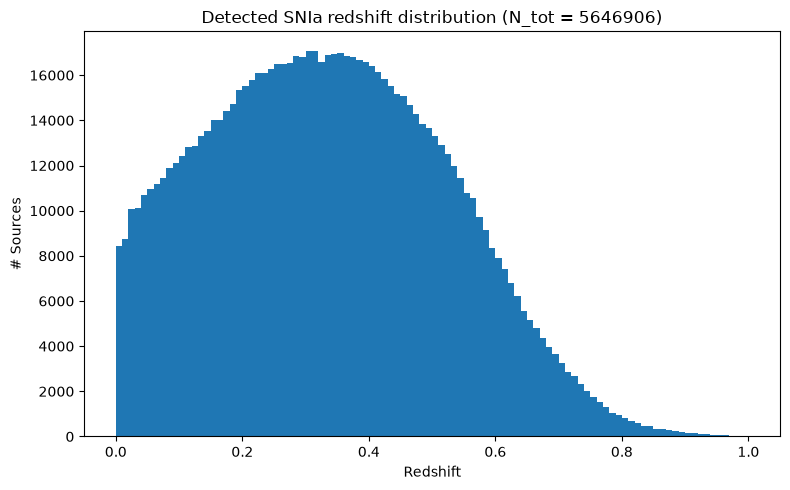

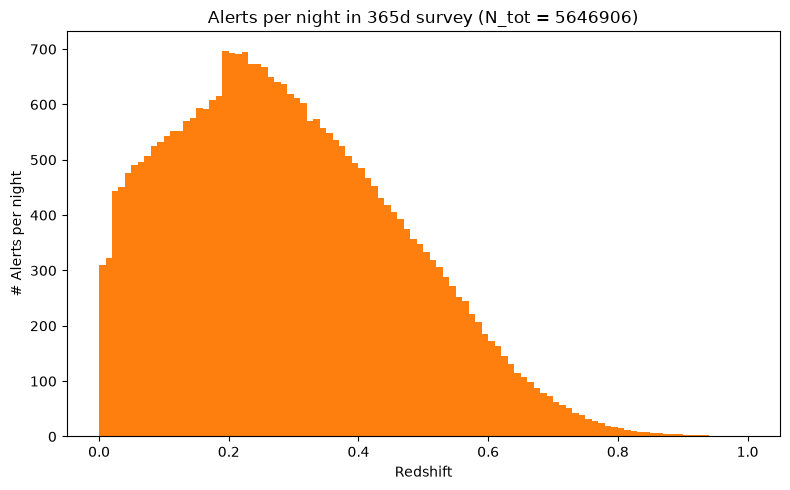

In [ ]:
# 1) number of detected sources per z-bin
N_tot = len(combined)

plt.figure(figsize=(8, 5))
plt.hist(detected["z"], bins=np.arange(0, 1.01, 0.01), color="tab:blue")
plt.xlabel("Redshift")
plt.ylabel("# Sources")
plt.title(f"Detected SNIa redshift distribution (N_tot = {N_tot})")
plt.tight_layout()
plt.show()

# 2) alerts per night per z-bin
plt.figure(figsize=(8, 5))
plt.hist(
    detected["z"],
    bins=np.arange(0, 1.01, 0.01),
    weights=detected["n_detections"] / 365.0,
    color="tab:orange"
)
plt.xlabel("Redshift")
plt.ylabel("# Alerts per night")
plt.title(f"Alerts per night in 365d survey (N_tot = {N_tot})")
plt.tight_layout()
plt.show()

In [ ]:
print(f"Total alerts per night: {detected['n_detections'].sum() / 365}")

Total alerts per night: 31026.002739726027


In [ ]:
len(detected) / 365, len(combined)/365

(2511.068493150685, 15471.002739726027)

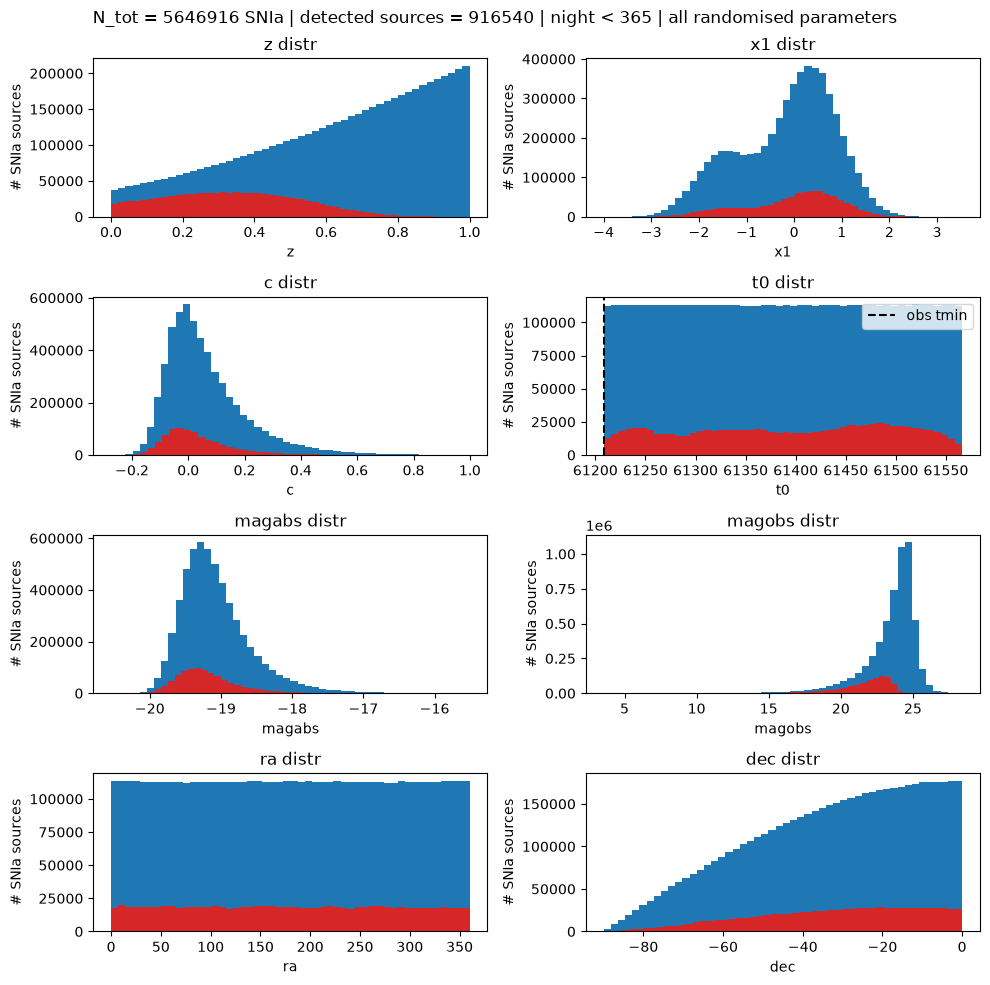

In [54]:
#perhaps this way, you don't need to specify bins?

detected_models = combined[combined['detected'] == True] # a df

params = ['z', 'x1', 'c', 't0', 'magabs', 'magobs', 'ra', 'dec']

fig, axs = plt.subplots(4, 2, figsize=(10, 10))

for ax, param in zip(axs.flat, params):
    ax.hist(combined[param], bins=50, color = 'tab:blue')
    ax.hist(detected_models[param], bins=50, color = 'tab:red')
    if param == 't0':
        ax.axvline(tmin, color = 'k', linestyle = '--', label = 'obs tmin')
        ax.legend()
    ax.set_xlabel(param)
    ax.set_ylabel("# SNIa sources")
    ax.set_title(f"{param} distr")

# Hide unused subplot
for ax in axs.flat[len(params):]:
    ax.set_visible(False)
plt.suptitle(f'N_tot = {N_tot} SNIa | detected sources = {len(detected_models)} | night < 365 | all randomised parameters')
plt.tight_layout()

plt.show()

### Checking that SNIa population aligns with observations

Redshift evolution of the underlying type Ia supernova stretch distributions: https://www.aanda.org/articles/aa/pdf/2021/05/aa38447-20.pdf
SNe Ia at higher redshift have a larger stretch (0.34 ± 0.10 at z ∼ 0.65) on average than those at lower redshift (−0.17 ± 0.10 at z ∼ 0.05), suggesting that the underlying stretch distribution evolves withredshift.

In [25]:
combined_highz = combined[(combined['z'] > 0.62) & (combined['z'] <= 0.68)]
combined_lowz = combined[(combined['z'] > 0.02) & (combined['z'] <= 0.08)]
combined_highz['x1'].describe(), combined_lowz['x1'].describe()

(count    407500.000000
 mean         -0.175570
 std           1.028694
 min          -3.985000
 25%          -0.925000
 50%           0.015000
 75%           0.585000
 max           3.160000
 Name: x1, dtype: float64,
 count    125624.000000
 mean         -0.175468
 std           1.028371
 min          -3.640000
 25%          -0.925000
 50%           0.015000
 75%           0.580000
 max           3.145000
 Name: x1, dtype: float64)

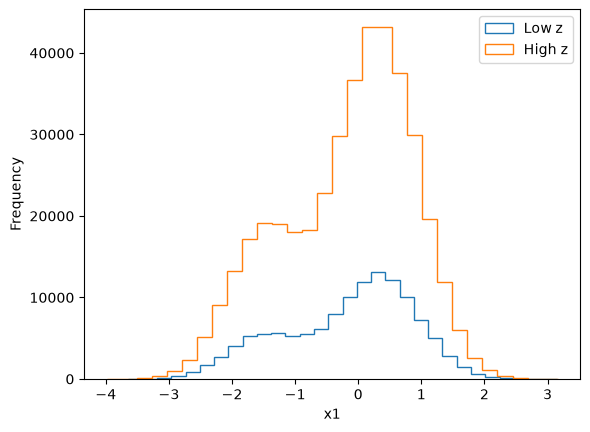

In [26]:
plt.hist(combined_lowz['x1'], histtype='step', label='Low z', color='tab:blue', bins=30)
plt.hist(combined_highz['x1'], histtype='step', label='High z', color='tab:orange', bins=30)
plt.xlabel('x1')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [28]:
combined['z'].max()

np.float32(1.0)